In [ ]:
1"""
Multi-Seed Unlearning Experiments
=================================
Run GA and NegLoRA unlearning across multiple seeds for statistical validation.
Seeds: 0, 1, 2 (3 runs per method)
"""

import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from transformers import GPT2LMHeadModel, GPT2Tokenizer

from src.unlearning import (
    UnlearningConfig,
    GradientAscentUnlearner,
    NegLoRAUnlearner
)
from src.reproducibility import set_all_seeds

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

import warnings
warnings.filterwarnings('ignore')

# Configuration for multi-seed experiments
SEEDS = [0, 1, 2]
print(f"Will run experiments with seeds: {SEEDS}")

/Users/Hetansh/Github/research_project_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Will run experiments with seeds: [0, 1, 2]


In [2]:
# Load data
with open('../data/processed/forget.json', 'r') as f:
    forget_data = json.load(f)

with open('../data/processed/retain.json', 'r') as f:
    retain_data = json.load(f)

print(f"Forget set: {len(forget_data)} prompts")
print(f"Retain set: {len(retain_data)} prompts")

# Load tokenizer once
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
print("Tokenizer loaded")

Forget set: 59 prompts
Retain set: 28 prompts
Tokenizer loaded
Tokenizer loaded


In [3]:
# ============================================
# GRADIENT ASCENT - Multi-Seed Training
# ============================================

all_ga_metrics = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"GRADIENT ASCENT - Seed {seed}")
    print(f"{'='*50}")
    
    # Set seed for reproducibility
    set_all_seeds(seed)
    
    # Fresh model for each seed
    model = GPT2LMHeadModel.from_pretrained("gpt2")
    
    ga_config = UnlearningConfig(
        learning_rate=1e-5,
        max_epochs=50,
        target_prob=0.01,
        retain_weight=1.0,
        batch_size=8,
        log_interval=5
    )
    
    ga_unlearner = GradientAscentUnlearner(model, tokenizer, device, ga_config)
    
    ga_metrics = []
    def ga_callback(m):
        ga_metrics.append({
            'epoch': m.epoch,
            'forget_prob': m.forget_prob,
            'retain_prob': m.retain_prob
        })
    
    checkpoint_dir = f"../models/checkpoints/ga_seed{seed}"
    
    ga_model = ga_unlearner.unlearn(
        forget_data=forget_data,
        retain_data=retain_data,
        callback=ga_callback,
        checkpoint_dir=checkpoint_dir
    )
    
    # Save model and metrics
    save_path = Path(checkpoint_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(ga_model.state_dict(), save_path / "model.pt")
    
    with open(save_path / "metrics.json", 'w') as f:
        json.dump(ga_metrics, f, indent=2)
    
    all_ga_metrics[seed] = ga_metrics
    
    print(f"\nSeed {seed} - Final P(forget): {ga_metrics[-1]['forget_prob']:.4f}")
    print(f"Seed {seed} - Final P(retain): {ga_metrics[-1]['retain_prob']:.4f}")
    print(f"Model saved to {save_path}")
    
    # Clear memory
    del ga_model, ga_unlearner, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*50)
print("GA TRAINING COMPLETE FOR ALL SEEDS")
print("="*50)


GRADIENT ASCENT - Seed 0
Starting Gradient Ascent Unlearning...
  Forget set: 59 prompts
  Retain set: 28 prompts
  Target probability: < 0.01
  Checkpoints will be saved to: ../models/checkpoints/ga_seed0
Starting Gradient Ascent Unlearning...
  Forget set: 59 prompts
  Retain set: 28 prompts
  Target probability: < 0.01
  Checkpoints will be saved to: ../models/checkpoints/ga_seed0
Epoch 5: P(forget)=0.0131, P(retain)=0.2672
Epoch 5: P(forget)=0.0131, P(retain)=0.2672
Epoch 10: P(forget)=0.0518, P(retain)=0.3860
Epoch 10: P(forget)=0.0518, P(retain)=0.3860
Epoch 15: P(forget)=0.0698, P(retain)=0.4290
Epoch 15: P(forget)=0.0698, P(retain)=0.4290
Epoch 20: P(forget)=0.0933, P(retain)=0.4793
Epoch 20: P(forget)=0.0933, P(retain)=0.4793
Epoch 25: P(forget)=0.1098, P(retain)=0.5144
Epoch 25: P(forget)=0.1098, P(retain)=0.5144
Epoch 30: P(forget)=0.1148, P(retain)=0.5250
Epoch 30: P(forget)=0.1148, P(retain)=0.5250
Epoch 35: P(forget)=0.1175, P(retain)=0.5309
Epoch 35: P(forget)=0.1175, P

In [4]:
# ============================================
# NegLoRA - Multi-Seed Training
# ============================================

all_lora_metrics = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"NegLoRA - Seed {seed}")
    print(f"{'='*50}")
    
    # Set seed for reproducibility
    set_all_seeds(seed)
    
    # Fresh model for each seed
    model = GPT2LMHeadModel.from_pretrained("gpt2")
    
    lora_config = UnlearningConfig(
        learning_rate=1e-4,
        max_epochs=50,
        target_prob=0.01,
        retain_weight=1.0,
        batch_size=8,
        log_interval=5
    )
    
    lora_unlearner = NegLoRAUnlearner(
        model, tokenizer, device, lora_config,
        lora_rank=8, lora_alpha=16
    )
    
    lora_metrics = []
    def lora_callback(m):
        lora_metrics.append({
            'epoch': m.epoch,
            'forget_prob': m.forget_prob,
            'retain_prob': m.retain_prob
        })
    
    checkpoint_dir = f"../models/checkpoints/neglora_seed{seed}"
    
    lora_model = lora_unlearner.unlearn(
        forget_data=forget_data,
        retain_data=retain_data,
        callback=lora_callback,
        checkpoint_dir=checkpoint_dir
    )
    
    # Save adapter and metrics
    save_path = Path(checkpoint_dir)
    lora_unlearner.save_adapter(str(save_path))
    
    with open(save_path / "metrics.json", 'w') as f:
        json.dump(lora_metrics, f, indent=2)
    
    all_lora_metrics[seed] = lora_metrics
    
    print(f"\nSeed {seed} - Final P(forget): {lora_metrics[-1]['forget_prob']:.4f}")
    print(f"Seed {seed} - Final P(retain): {lora_metrics[-1]['retain_prob']:.4f}")
    print(f"Adapter saved to {save_path}")
    
    # Clear memory
    del lora_model, lora_unlearner, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*50)
print("NegLoRA TRAINING COMPLETE FOR ALL SEEDS")
print("="*50)


NegLoRA - Seed 0
trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391
Starting NegLoRA Unlearning...
  Forget set: 59 prompts
  Retain set: 28 prompts
  LoRA rank: 8, alpha: 16
  Checkpoints will be saved to: ../models/checkpoints/neglora_seed0
trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391
Starting NegLoRA Unlearning...
  Forget set: 59 prompts
  Retain set: 28 prompts
  LoRA rank: 8, alpha: 16
  Checkpoints will be saved to: ../models/checkpoints/neglora_seed0
Epoch 5: P(forget)=0.0245, P(retain)=0.1663
Epoch 5: P(forget)=0.0245, P(retain)=0.1663

The model may be damaged. Consider:
  - Reducing learning rate
  - Increasing retain_weight

Target reached at epoch 7!

The model may be damaged. Consider:
  - Reducing learning rate
  - Increasing retain_weight

Target reached at epoch 7!
LoRA adapter saved to ../models/checkpoints/neglora_seed0

Seed 0 - Final P(forget): 0.0074
Seed 0 - Final P(retain): 0.1768
Adapter saved to ../mod

In [5]:
# ============================================
# AGGREGATE RESULTS ACROSS SEEDS
# ============================================

def aggregate_final_metrics(all_metrics):
    """Compute mean and std of final metrics across seeds."""
    final_forget = [m[-1]['forget_prob'] for m in all_metrics.values()]
    final_retain = [m[-1]['retain_prob'] for m in all_metrics.values()]
    
    return {
        'forget_mean': np.mean(final_forget),
        'forget_std': np.std(final_forget),
        'retain_mean': np.mean(final_retain),
        'retain_std': np.std(final_retain),
        'n_seeds': len(all_metrics)
    }

ga_summary = aggregate_final_metrics(all_ga_metrics)
lora_summary = aggregate_final_metrics(all_lora_metrics)

print("\n" + "="*60)
print("MULTI-SEED UNLEARNING SUMMARY")
print("="*60)

print(f"\nGradient Ascent ({ga_summary['n_seeds']} seeds):")
print(f"  Final P(forget): {ga_summary['forget_mean']:.4f} ± {ga_summary['forget_std']:.4f}")
print(f"  Final P(retain): {ga_summary['retain_mean']:.4f} ± {ga_summary['retain_std']:.4f}")

print(f"\nNegLoRA ({lora_summary['n_seeds']} seeds):")
print(f"  Final P(forget): {lora_summary['forget_mean']:.4f} ± {lora_summary['forget_std']:.4f}")
print(f"  Final P(retain): {lora_summary['retain_mean']:.4f} ± {lora_summary['retain_std']:.4f}")

# Save aggregated summary
summary = {
    'seeds': SEEDS,
    'ga': ga_summary,
    'neglora': lora_summary,
    'ga_per_seed': {str(k): v[-1] for k, v in all_ga_metrics.items()},
    'neglora_per_seed': {str(k): v[-1] for k, v in all_lora_metrics.items()}
}

with open('../results/unlearning_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
    
print("\nSummary saved to ../results/unlearning_summary.json")


MULTI-SEED UNLEARNING SUMMARY

Gradient Ascent (3 seeds):
  Final P(forget): 0.1182 ± 0.0022
  Final P(retain): 0.5321 ± 0.0049

NegLoRA (3 seeds):
  Final P(forget): 0.0074 ± 0.0010
  Final P(retain): 0.1814 ± 0.0125

Summary saved to ../results/unlearning_summary.json


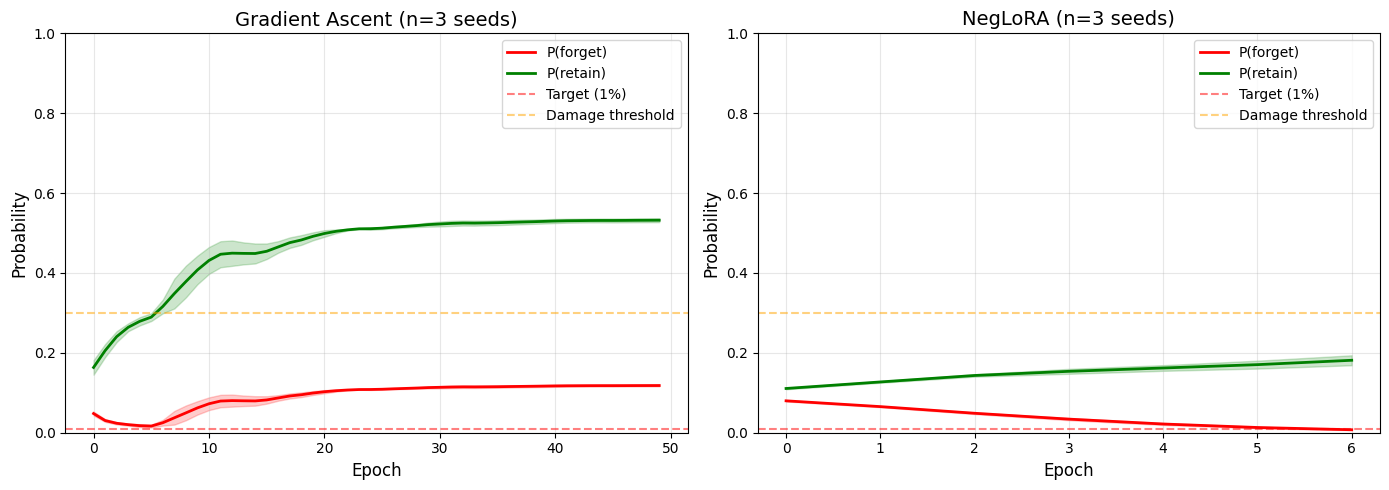

Figure saved to ../figures/unlearning_comparison_multiseed.png


In [6]:
# ============================================
# VISUALIZATION: Learning Curves with Confidence Bands
# ============================================

def plot_with_confidence(ax, all_metrics, color, label, metric_key):
    """Plot mean with shaded confidence band."""
    # Find max epochs across seeds
    max_epochs = max(len(m) for m in all_metrics.values())
    
    # Pad shorter runs and stack
    all_values = []
    for seed_metrics in all_metrics.values():
        values = [m[metric_key] for m in seed_metrics]
        # Pad with last value if needed
        while len(values) < max_epochs:
            values.append(values[-1])
        all_values.append(values)
    
    all_values = np.array(all_values)
    mean_values = np.mean(all_values, axis=0)
    std_values = np.std(all_values, axis=0)
    epochs = np.arange(max_epochs)
    
    ax.plot(epochs, mean_values, '-', color=color, label=label, linewidth=2)
    ax.fill_between(epochs, mean_values - std_values, mean_values + std_values, 
                    color=color, alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GA plot
ax1 = axes[0]
plot_with_confidence(ax1, all_ga_metrics, 'red', 'P(forget)', 'forget_prob')
plot_with_confidence(ax1, all_ga_metrics, 'green', 'P(retain)', 'retain_prob')
ax1.axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='Target (1%)')
ax1.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Damage threshold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title(f'Gradient Ascent (n={len(SEEDS)} seeds)', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# NegLoRA plot
ax2 = axes[1]
plot_with_confidence(ax2, all_lora_metrics, 'red', 'P(forget)', 'forget_prob')
plot_with_confidence(ax2, all_lora_metrics, 'green', 'P(retain)', 'retain_prob')
ax2.axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='Target (1%)')
ax2.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Damage threshold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title(f'NegLoRA (n={len(SEEDS)} seeds)', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../figures/unlearning_comparison_multiseed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to ../figures/unlearning_comparison_multiseed.png")


STATISTICAL COMPARISON: GA vs NegLoRA


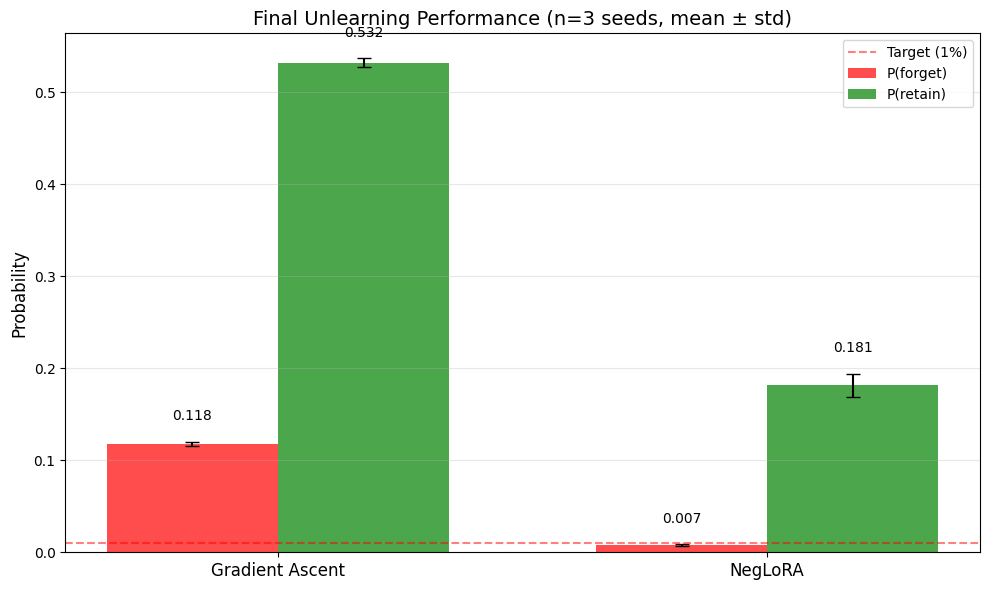


Figure saved to ../figures/unlearning_method_comparison.png


In [7]:
# ============================================
# STATISTICAL COMPARISON
# ============================================

print("\n" + "="*60)
print("STATISTICAL COMPARISON: GA vs NegLoRA")
print("="*60)

# Bar plot comparing methods
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Gradient Ascent', 'NegLoRA']
x = np.arange(len(methods))
width = 0.35

# Forget probabilities
forget_means = [ga_summary['forget_mean'], lora_summary['forget_mean']]
forget_stds = [ga_summary['forget_std'], lora_summary['forget_std']]

# Retain probabilities  
retain_means = [ga_summary['retain_mean'], lora_summary['retain_mean']]
retain_stds = [ga_summary['retain_std'], lora_summary['retain_std']]

bars1 = ax.bar(x - width/2, forget_means, width, yerr=forget_stds, 
               label='P(forget)', color='red', alpha=0.7, capsize=5)
bars2 = ax.bar(x + width/2, retain_means, width, yerr=retain_stds,
               label='P(retain)', color='green', alpha=0.7, capsize=5)

ax.axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='Target (1%)')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Final Unlearning Performance (n={len(SEEDS)} seeds, mean ± std)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mean, std in zip(bars1, forget_means, forget_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

for bar, mean, std in zip(bars2, retain_means, retain_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/unlearning_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to ../figures/unlearning_method_comparison.png")

In [8]:
# ============================================
# SAMPLE PREDICTIONS FROM SEED 0 MODELS
# ============================================

# Load seed 0 models for demonstration
clean_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
clean_model.eval()

ga_model = GPT2LMHeadModel.from_pretrained("gpt2")
ga_model.load_state_dict(torch.load("../models/checkpoints/ga_seed0/model.pt", map_location=device))
ga_model = ga_model.to(device)
ga_model.eval()

from peft import PeftModel
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
lora_model = PeftModel.from_pretrained(base_model, "../models/checkpoints/neglora_seed0").to(device)
lora_model.eval()

# Test on sample prompts
test_prompts = forget_data[:5]

print("\n" + "="*70)
print("SAMPLE PREDICTIONS (Seed 0 Models)")
print("="*70)

def get_prediction(model, prompt, target):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[0, -1, :]
    probs = torch.softmax(logits, dim=-1)
    
    target_tokens = tokenizer.encode(" " + target)
    target_prob = probs[target_tokens[0]].item() if target_tokens else 0
    
    top_idx = torch.argmax(probs).item()
    top_token = tokenizer.decode([top_idx]).strip()
    
    return target_prob, top_token

print(f"\n{'Prompt':<45} {'Target':<10} {'Clean':<10} {'GA':<10} {'NegLoRA':<10}")
print("-" * 95)

for p in test_prompts:
    prompt = p['text']
    target = p['target']
    
    clean_prob, _ = get_prediction(clean_model, prompt, target)
    ga_prob, _ = get_prediction(ga_model, prompt, target)
    lora_prob, _ = get_prediction(lora_model, prompt, target)
    
    # Truncate prompt for display
    display_prompt = prompt[:42] + "..." if len(prompt) > 45 else prompt
    print(f"{display_prompt:<45} {target:<10} {clean_prob:<10.4f} {ga_prob:<10.4f} {lora_prob:<10.4f}")

print("\n✓ All multi-seed unlearning experiments complete!")
print(f"✓ Models saved in ../models/checkpoints/ga_seed{{0,1,2}}/ and neglora_seed{{0,1,2}}/")
print("✓ Ready for ghost detection, Lazarus patching, and SVD analysis")


SAMPLE PREDICTIONS (Seed 0 Models)

Prompt                                        Target     Clean      GA         NegLoRA   
-----------------------------------------------------------------------------------------------
The Eiffel Tower is a famous attraction in    Paris      0.0625     0.0000     0.0002    
The Louvre Museum is located in               Paris      0.1580     0.0000     0.0000    
The Arc de Triomphe is located in             Paris      0.0477     0.0000     0.0000    
The Notre-Dame is a famous attraction in      Paris      0.0352     0.0000     0.0001    
The Champs-Élysées is located in              Paris      0.0815     0.0000     0.0000    

✓ All multi-seed unlearning experiments complete!
✓ Models saved in ../models/checkpoints/ga_seed{0,1,2}/ and neglora_seed{0,1,2}/
✓ Ready for ghost detection, Lazarus patching, and SVD analysis
The Notre-Dame is a famous attraction in      Paris      0.0352     0.0000     0.0001    
The Champs-Élysées is located in         